In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [17]:
# read csv file 
results = pd.read_csv("baseline_results.csv")
print(results.head())
print(results.tail())
print(results.shape)

  model dataset  max_trees  no_trees  depth    alpha  train_loss  \
0  cegb  kin8nm          1         1      2  0.50000    0.069549   
1  cegb  kin8nm          4         1      8  0.50000    0.069549   
2  cegb  kin8nm          4         1      1  0.03125    0.069549   
3  cegb  kin8nm          1         1      4  0.12500    0.069549   
4  cegb  kin8nm          8         1      1  0.12500    0.069549   

   test_accuracy  nodes  
0       0.069205      1  
1       0.069205      1  
2       0.069205      1  
3       0.069205      1  
4       0.069205      1  
     model        dataset  max_trees  no_trees  depth     alpha  train_loss  \
6330   ccp  covtype_multi       1024      1024      8  0.500000    1.205100   
6331   ccp  covtype_multi       1024      1024      8  0.062500    1.205100   
6332   ccp  covtype_multi       1024      1024      8  0.015625    1.058577   
6333   ccp  covtype_multi       1024      1024      8  0.007812    0.975246   
6334   ccp  covtype_multi       1024    

In [18]:
# add column for memory usage calculated by 64 * nodes if model is lgbm_quant, otherwise 128 * nodes
results['memory_usage'] = results.apply(lambda row: 64 * row['nodes'] if row['model'] in ['lgbm_quant', 'ccp'] else 128 * row['nodes'], axis=1)

In [12]:
# get all rows with memory usage below 100000 and test accuracy above 0.9
results[(results['memory_usage'] <= 10000) & (results['test_accuracy'] >= 0.95) & (results['dataset'] == 'breastcancer')]

,model,dataset,max_trees,no_trees,depth,alpha,train_loss,test_accuracy,nodes,memory_usage
19,cegb,breastcancer,16,16,2,0.062500,0.962637,0.956140,74,9472
20,cegb,breastcancer,8,8,2,0.015625,0.962637,0.956140,54,6912
194,cegb,breastcancer,8,8,2,0.007812,0.962637,0.956140,54,6912
755,cegb,breastcancer,8,8,2,0.000000,0.962637,0.956140,56,7168
782,cegb,breastcancer,8,8,8,0.062500,0.964835,0.956140,52,6656
964,cegb,breastcancer,8,8,8,0.031250,0.967033,0.956140,58,7424
1127,cegb,breastcancer,8,8,4,0.062500,0.964835,0.956140,52,6656
1156,cegb,breastcancer,8,8,8,0.015625,0.960440,0.956140,74,9472
1314,cegb,breastcancer,8,8,4,0.031250,0.967033,0.956140,58,7424
1348,cegb,breastcancer,8,8,8,0.007812,0.960440,0.956140,76,9728


In [13]:
datasets = ["breastcancer", "kr-vs-kp", "covtype", "mushroom", "wine", "covtype_multi"]
# datasets = ["wine", "covtype_multi"]
# datasets = ["kin8nm", "california_housing"]
memory_limit_kb = 2
memory_limit = memory_limit_kb * 8000 # bits
# for each type of model find the best result for each dataset based on the highest test score that is below a memory usage of 100000
best_results = results[(results['memory_usage'] <= memory_limit) & (results['dataset'].isin(datasets))].groupby(['model', 'dataset'])['test_accuracy'].idxmax()
print(results.loc[best_results])

           model        dataset  max_trees  no_trees  depth     alpha  \
5318         ccp   breastcancer         32        32      1  0.000000   
3248         ccp        covtype          8         8      4  0.000000   
5264         ccp  covtype_multi         16        16      2  0.007812   
5836         ccp       kr-vs-kp          2         2      8  0.000000   
3094         ccp       mushroom          1         1      8  0.000000   
4112         ccp           wine         16        16      4  0.007812   
328         cegb   breastcancer        256        33      1  0.031250   
2327        cegb        covtype          2         2      8  0.015625   
1115        cegb  covtype_multi         16        42      2  0.062500   
2409        cegb       kr-vs-kp          2         2      8  0.000000   
221         cegb       mushroom          2         2      8  0.062500   
75          cegb           wine          8        56      2  0.031250   
4510   lgbm_base   breastcancer         32        3

In [14]:
datasets = ["breastcancer", "kr-vs-kp", "covtype", "mushroom", "wine", "covtype_multi"]
# datasets = ["wine", "covtype_multi"]
# datasets = ["kin8nm", "california_housing"]
memory_limit_kb = [0.5, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
# memory_limits = memory_limit_kb * 8000
memory_limits = [int(x * 8000) for x in memory_limit_kb]
# create empty pandas dataframe to store results
df_res = pd.DataFrame()
# for each type of model find the best result for each dataset based on the highest test score that is below a memory usage of 100000
for memory in memory_limits:
    best_results_ids = results[(results['memory_usage'] <= memory) & (results['dataset'].isin(datasets))].groupby(['model', 'dataset'])['test_accuracy'].idxmax()
    best_results = results.loc[best_results_ids]
    best_results['max_memory'] = memory
    df_res = pd.concat([df_res, best_results])

In [15]:
df_res

,model,dataset,max_trees,no_trees,depth,alpha,train_loss,test_accuracy,nodes,memory_usage,max_memory
5313,ccp,breastcancer,16,16,4,0.015625,0.455035,0.956140,52,3328,4000
3609,ccp,covtype,2,2,4,0.000000,1.285550,0.750626,62,3968,4000
4718,ccp,covtype_multi,4,4,2,0.031250,1.150659,0.631257,36,2304,4000
5658,ccp,kr-vs-kp,1,1,8,0.015625,1.233235,0.931250,9,576,4000
3257,ccp,mushroom,1,1,4,0.000000,1.208481,0.974154,29,1856,4000
...,...,...,...,...,...,...,...,...,...,...,...
4847,lgbm_quant,covtype,512,512,8,0.000000,NaN,0.897042,31232,1998848,16384000
5626,lgbm_quant,covtype_multi,128,896,8,0.000000,NaN,0.857921,54656,3497984,16384000
3492,lgbm_quant,kr-vs-kp,64,64,8,0.000000,NaN,0.982812,3736,239104,16384000
4835,lgbm_quant,mushroom,32,32,8,0.000000,NaN,1.000000,1868,119552,16384000


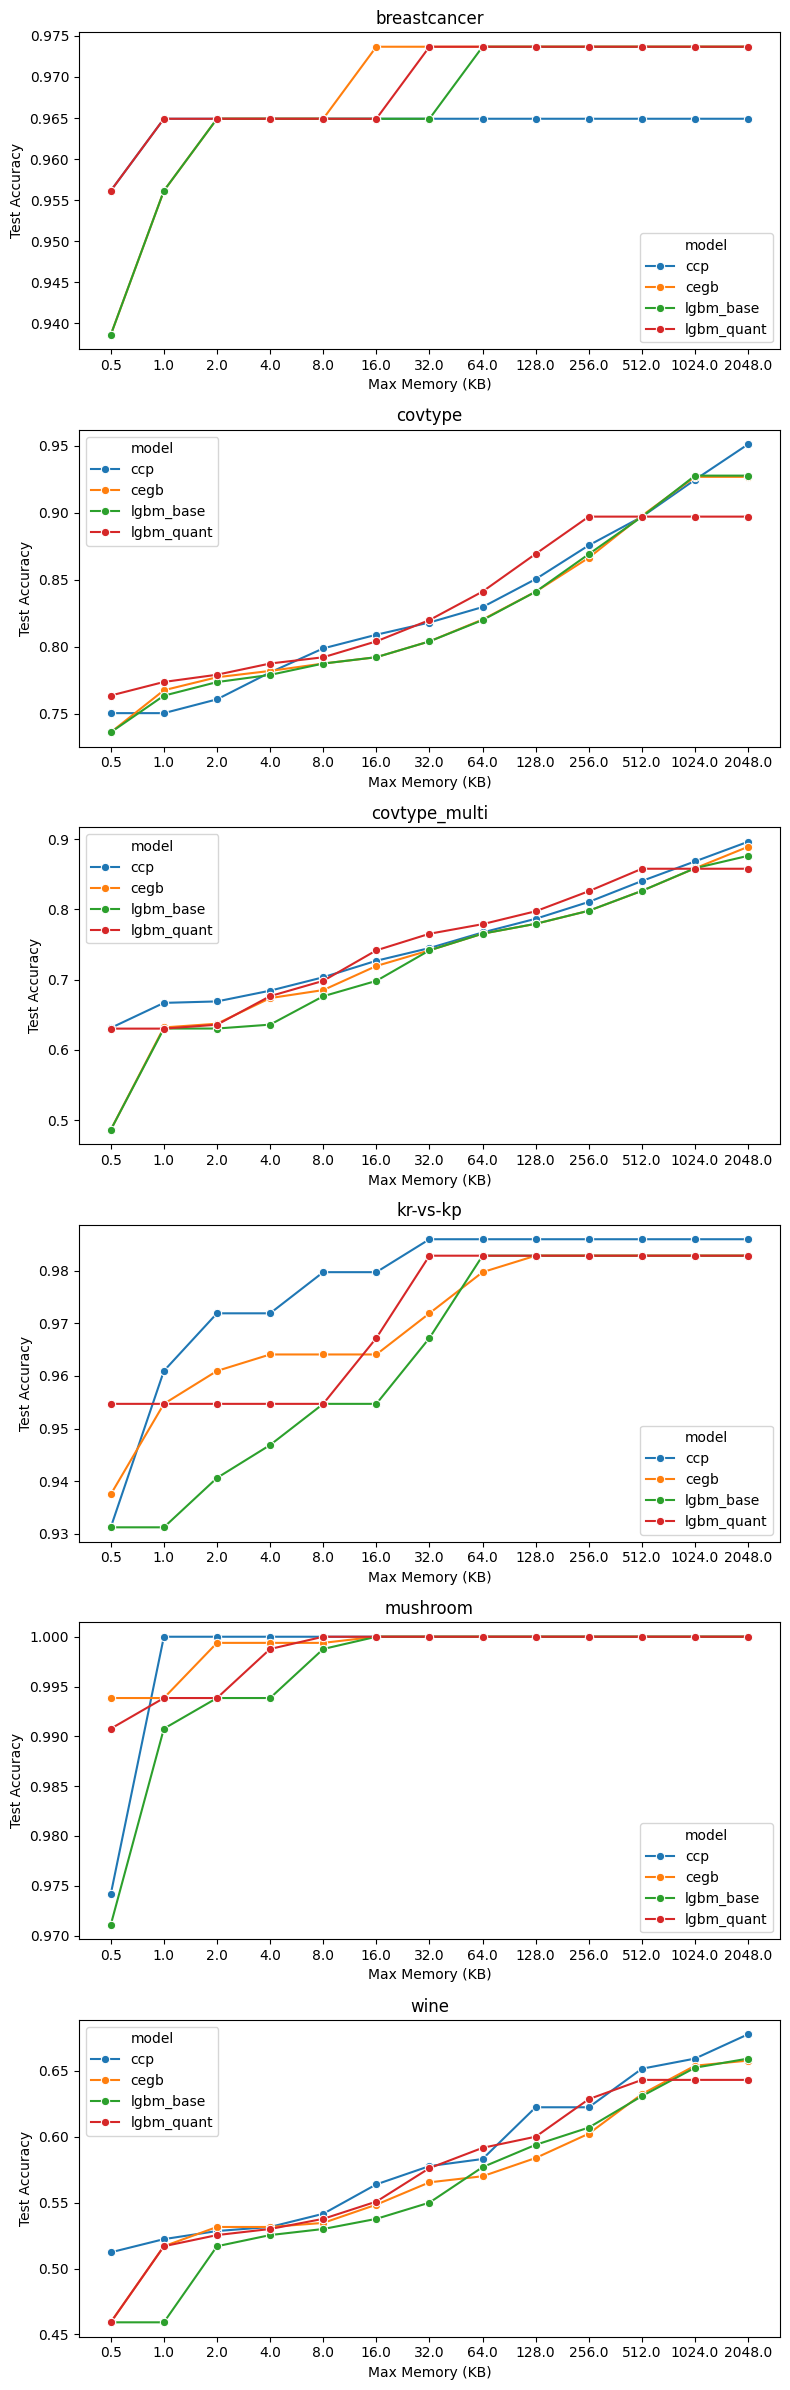

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

datasets_unique = df_res['dataset'].unique()
n_datasets = len(datasets_unique)
fig, axes = plt.subplots(n_datasets, 1, figsize=(8, 4 * n_datasets))

for ax, dataset in zip(axes, datasets_unique):
    data = df_res[df_res['dataset'] == dataset].copy()
    # Convert max_memory to string for categorical x-axis
    data['max_memory'] = (data['max_memory']/8000).astype(str)
    l = sns.lineplot(
        data=data,
        x='max_memory',
        y='test_accuracy',
        hue='model',
        marker='o',
        ax=ax
    )
    ax.set_title(dataset)
    ax.set_xlabel("Max Memory (KB)")
    ax.set_ylabel("Test Accuracy")

plt.tight_layout()
plt.show()

# Baseline vs. ToaD

In [92]:
results_folder = '../../evaluation/testdata/results_base2'
# read csv file 
baseline_results = pd.read_csv("baseline_results.csv")

# add column for memory usage calculated by 64 * nodes if model is lgbm_quant, otherwise 128 * nodes
baseline_results['memory_usage'] = baseline_results.apply(lambda row: 64 * row['nodes'] if row['model'] in ['lgbm_quant', 'ccp'] else 128 * row['nodes'], axis=1)

# get all rows with memory usage below 100000 and test accuracy above 0.9
# baseline_results[(baseline_results['memory_usage'] <= 10000) & (baseline_results['test_accuracy'] >= 0.95) & (baseline_results['dataset'] == 'breastcancer')]

regression_datasets = ["kin8nm", "california_housing"]
classification_datasets = ["breastcancer", "kr-vs-kp", "covtype", "mushroom", "wine", "covtype_multi"]
# datasets = ["wine", "covtype_multi"]
# datasets = ["kin8nm", "california_housing"]
memory_limit_kb = 2
memory_limit = memory_limit_kb * 8000 # bits

datasets = ["breastcancer", "kr-vs-kp", "covtype", "mushroom", "wine", "covtype_multi", "kin8nm", "california_housing"]
# datasets = ["wine", "covtype_multi"]
# datasets = ["kin8nm", "california_housing"]
memory_limit_kb = [0.5, 1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
# memory_limits = memory_limit_kb * 8000
memory_limits = [int(x * 8000) for x in memory_limit_kb]
# create empty pandas dataframe to store results
df_baseline_res = pd.DataFrame()
# for each type of model find the best result for each dataset based on the highest test score that is below a memory usage of 100000
for memory in memory_limits:
    best_classification_results_ids = baseline_results[(baseline_results['memory_usage'] <= memory) & (baseline_results['dataset'].isin(classification_datasets))].groupby(['model', 'dataset'])['test_accuracy'].idxmax()
    best_regression_results_ids = baseline_results[(baseline_results['memory_usage'] <= memory) & (baseline_results['dataset'].isin(regression_datasets))].groupby(['model', 'dataset'])['test_accuracy'].idxmin()
    best_results_ids = pd.concat([best_classification_results_ids, best_regression_results_ids])
    best_results = baseline_results.loc[best_results_ids]
    best_results['max_memory'] = memory
    df_baseline_res = pd.concat([df_baseline_res, best_results])
results_all = df_baseline_res.copy()

In [93]:
df_baseline_res

,model,dataset,max_trees,no_trees,depth,alpha,train_loss,test_accuracy,nodes,memory_usage,max_memory
5313,ccp,breastcancer,16,16,4,0.015625,0.455035,0.956140,52,3328,4000
3609,ccp,covtype,2,2,4,0.000000,1.285550,0.750626,62,3968,4000
4718,ccp,covtype_multi,4,4,2,0.031250,1.150659,0.631257,36,2304,4000
5658,ccp,kr-vs-kp,1,1,8,0.015625,1.233235,0.931250,9,576,4000
3257,ccp,mushroom,1,1,4,0.000000,1.208481,0.974154,29,1856,4000
...,...,...,...,...,...,...,...,...,...,...,...
1098,cegb,kin8nm,1024,1024,8,0.000000,0.000339,0.011853,60700,7769600,16384000
5024,lgbm_base,california_housing,1024,1024,8,0.000000,0.034140,0.187950,62342,7979776,16384000
5126,lgbm_base,kin8nm,1024,1024,8,0.000000,0.000328,0.012218,61004,7808512,16384000
4971,lgbm_quant,california_housing,128,128,8,0.000000,NaN,0.213489,7808,499712,16384000


In [98]:
datasets = ["breastcancer", "kr-vs-kp", "covtype", "mushroom", "wine", "covtype_multi", "kin8nm", "california_housing"]
for data in datasets:
    path = os.path.join(results_folder, data, 'results.csv')
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    for memory in memory_limits:
        subset_pen = df[(df['our_bits'] <= memory) & (df['tinygbdt_penalty_feature'] != 0) & (df['tinygbdt_penalty_split'] != 0)]
        if subset_pen.empty:
            print(f"No ToaD with penalty for {data} and memory {memory}")
        else: # not subset_pen.empty:
            if data in regression_datasets:
                best_row = subset_pen.loc[subset_pen['accuracy'].idxmin()]
                print(best_row)
            else:
                best_row = subset_pen.loc[subset_pen['accuracy'].idxmax()] 
            filled = {
                "model": "toad_pen",
                "dataset": data,
                "max_trees": best_row.max_trees,
                "no_trees": best_row.no_trees,
                "depth": best_row.max_depth,
                "alpha": 0,
                "train_loss": 1e+34,
                "test_accuracy": best_row.accuracy,
                "nodes": best_row.no_leaves*2-1,
                "memory_usage": best_row.our_bits,
                "max_memory": memory
            }
            # print(filled)
            # add filled as new row to df_baseline_res
            results_all = pd.concat([results_all, pd.DataFrame([filled])], ignore_index=True)
        subset_nopen = df[(df['our_bits'] <= memory) & (df['tinygbdt_penalty_feature'] == 0) & (df['tinygbdt_penalty_split'] == 0)]


no_trees                    1.000000e+00
max_trees                   2.560000e+02
max_depth                   1.000000e+00
no_features                 1.000000e+00
no_thresholds               1.000000e+00
no_leaves                   1.000000e+00
our_bits                    3.500000e+01
lgb_bits                    3.200000e+01
accuracy                   -1.873037e-04
tinygbdt_penalty_feature    1.024000e+03
tinygbdt_penalty_split      8.000000e+00
tinygbdt_forestsize         6.400000e+06
Name: 0, dtype: float64
no_trees                    1.000000e+00
max_trees                   2.560000e+02
max_depth                   1.000000e+00
no_features                 1.000000e+00
no_thresholds               1.000000e+00
no_leaves                   1.000000e+00
our_bits                    3.500000e+01
lgb_bits                    3.200000e+01
accuracy                   -1.873037e-04
tinygbdt_penalty_feature    1.024000e+03
tinygbdt_penalty_split      8.000000e+00
tinygbdt_forestsize         6.400

In [95]:
results_all

,model,dataset,max_trees,no_trees,depth,alpha,train_loss,test_accuracy,nodes,memory_usage,max_memory
0,ccp,breastcancer,16.0,16.0,4.0,0.015625,4.550352e-01,0.956140,52.0,3328.0,4000
1,ccp,covtype,2.0,2.0,4.0,0.000000,1.285550e+00,0.750626,62.0,3968.0,4000
2,ccp,covtype_multi,4.0,4.0,2.0,0.031250,1.150659e+00,0.631257,36.0,2304.0,4000
3,ccp,kr-vs-kp,1.0,1.0,8.0,0.015625,1.233235e+00,0.931250,9.0,576.0,4000
4,ccp,mushroom,1.0,1.0,4.0,0.000000,1.208481e+00,0.974154,29.0,1856.0,4000
...,...,...,...,...,...,...,...,...,...,...,...
515,toad_pen,california_housing,8.0,1.0,2.0,0.000000,1.000000e+34,-0.000219,1.0,39.0,1024000
516,toad_pen,california_housing,8.0,1.0,2.0,0.000000,1.000000e+34,-0.000219,1.0,39.0,2048000
517,toad_pen,california_housing,8.0,1.0,2.0,0.000000,1.000000e+34,-0.000219,1.0,39.0,4096000
518,toad_pen,california_housing,8.0,1.0,2.0,0.000000,1.000000e+34,-0.000219,1.0,39.0,8192000


['breastcancer' 'covtype' 'covtype_multi' 'kr-vs-kp' 'mushroom' 'wine'
 'california_housing' 'kin8nm']


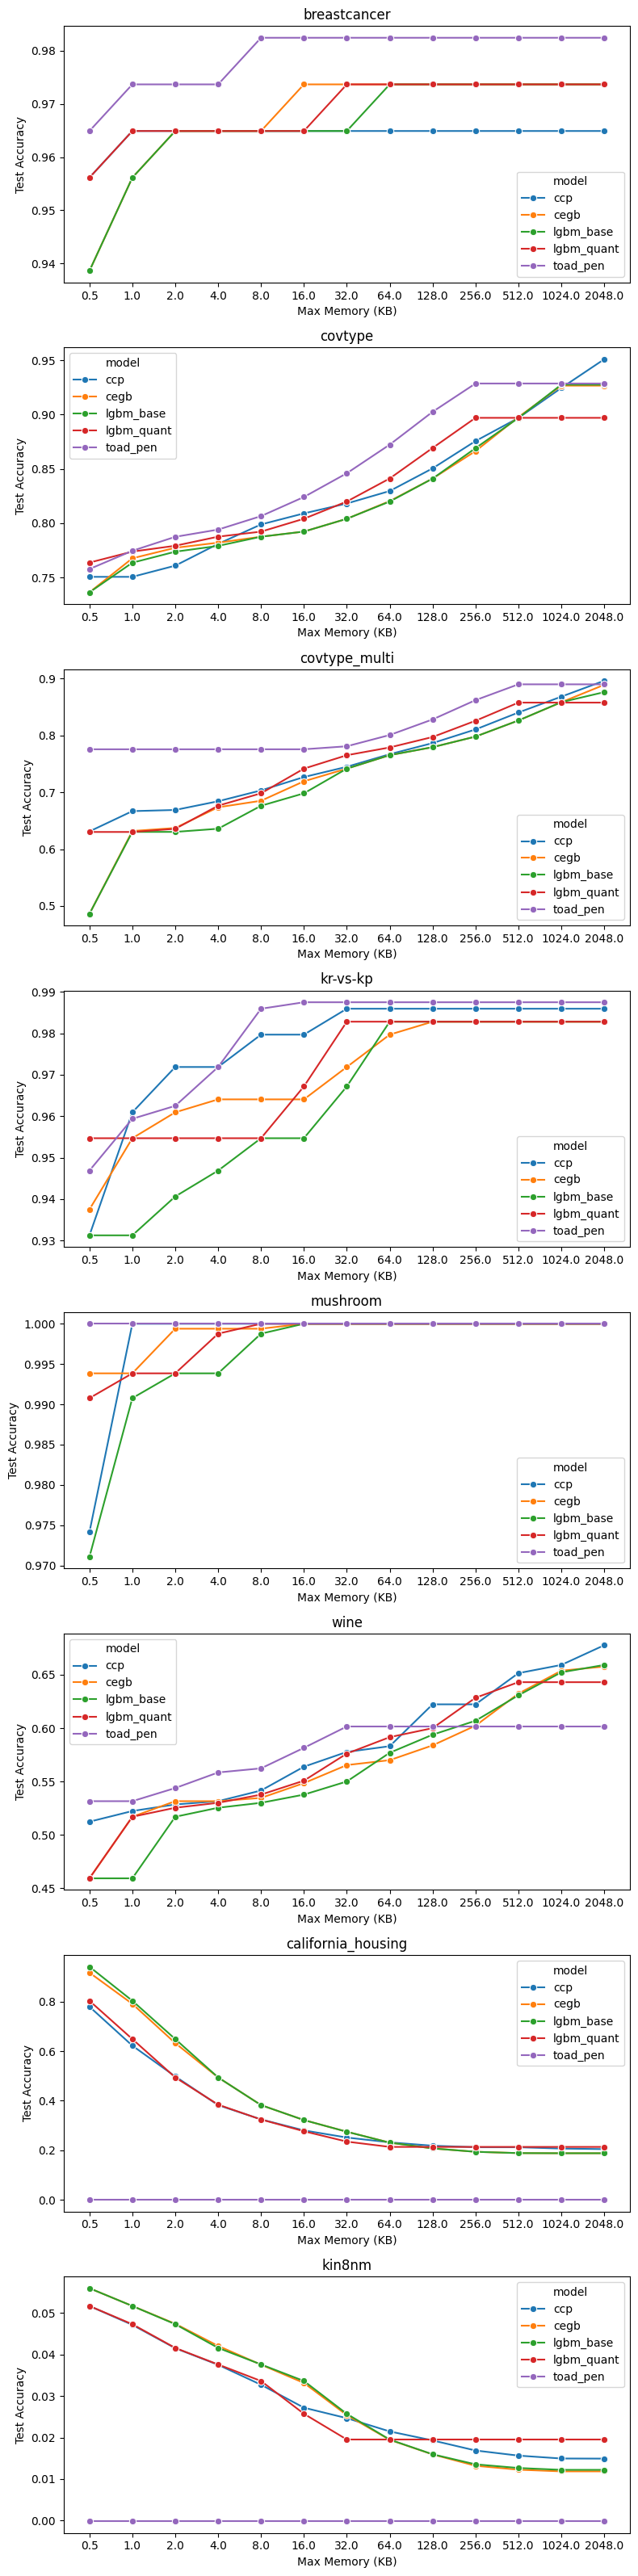

In [96]:
df = results_all
datasets_unique = df['dataset'].unique()
print(datasets_unique)
n_datasets = len(datasets_unique)

fig, axes = plt.subplots(n_datasets, 1, figsize=(8, 4 * n_datasets))
for ax, dataset in zip(axes, datasets_unique):
    data = df[df['dataset'] == dataset].copy()
    # Convert max_memory to string for categorical x-axis
    data['max_memory'] = (data['max_memory']/8000).astype(str)
    # if dataset is "california_housing" or "kin8nm" annotate y axis with "error"
    if dataset in ["california_housing", "kin8nm"]:
        ax.set_ylabel("Test Error")
        # data['test_accuracy'] = 1 - data['test_accuracy']
    l = sns.lineplot(
        data=data,
        x='max_memory',
        y='test_accuracy',
        hue='model',
        marker='o',
        ax=ax
    )
    ax.set_title(dataset)
    ax.set_xlabel("Max Memory (KB)")
    ax.set_ylabel("Test Accuracy")

plt.tight_layout()
plt.show()

# Preprocess 
ill formatted csv file that has line breaks within training score arrays

In [ ]:
import re
import csv

input_file = "input.csv"
output_file = "output.csv"

# Step 1: Read whole file as text
with open(input_file, "r", encoding="utf-8") as f:
    text = f.read()

# Step 2: Merge multi-line bracketed fields into a single line
# This regex finds [ ... ] possibly spanning multiple lines
text = re.sub(r"\[(.*?)\]", 
              lambda m: "[" + " ".join(m.group(1).split()) + "]", 
              text, 
              flags=re.S)

# Step 3: Parse with CSV reader
rows = []
for row in csv.reader(text.splitlines()):
    new_row = []
    for field in row:
        if field.startswith("[") and field.endswith("]"):
            # Extract numbers inside brackets
            numbers = re.findall(r"[-+]?\d*\.\d+|\d+", field)
            new_row.append(numbers[-1] if numbers else "")
        else:
            new_row.append(field)
    rows.append(new_row)

# Step 4: Write cleaned CSV
with open(output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(rows)
